In [1]:
import torch
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt

from conn import DeBERTaEncoder

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
MODEL_NAME = "microsoft/deberta-v3-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
encoder = DeBERTaEncoder(model, tokenizer, DEVICE)

print("device:", DEVICE)
print("model:", MODEL_NAME)

/opt/miniconda3/envs/connections/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 102/102 [00:00<00:00, 917.89it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_p

device: mps
model: microsoft/deberta-v3-small


In [2]:
N_TRAIN = 200
N_EVAL = 50
EPOCHS = 3
BATCH_SIZE = 4
LR = 2e-4
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
TEMPERATURE = 0.07
ADAPTER_DIR = "adapters/deberta-lora"
VERBOSE = False

In [3]:
from data_loader import load_connections_from_hf, gold_example_groups_from_row

hf_split = load_connections_from_hf()
print(f"Total puzzles: {len(hf_split)}")

train_puzzles = [hf_split[i] for i in range(N_TRAIN)]
eval_puzzles = [hf_split[i] for i in range(N_TRAIN, N_TRAIN + N_EVAL)]
print(f"Train: {len(train_puzzles)}, Eval: {len(eval_puzzles)}")

Total puzzles: 652
Train: 200, Eval: 50


In [4]:
from conn import finetune_deberta_lora

print("Starting fine-tuning...")

ft_encoder, stats = finetune_deberta_lora(
    puzzles=train_puzzles,
    model_name=MODEL_NAME,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    temperature=TEMPERATURE,
    lora_r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    adapter_output_dir=ADAPTER_DIR,
    verbose=True,
)

print(f"Training complete: {stats.epochs} epochs, {stats.steps} steps")
print(f"Final avg loss: {stats.average_losses[-1]:.4f}")

Starting fine-tuning...
Starting LoRA fine-tuning on mps for 3 epochs...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1594.74it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Epoch 1/3 | Average Loss: 0.3015
Epoch 2/3 | Average Loss: 0.2944
Epoch 3/3 | Average Loss: 0.2925
Training complete: 3 epochs, 2700 steps
Final avg loss: 0.2925


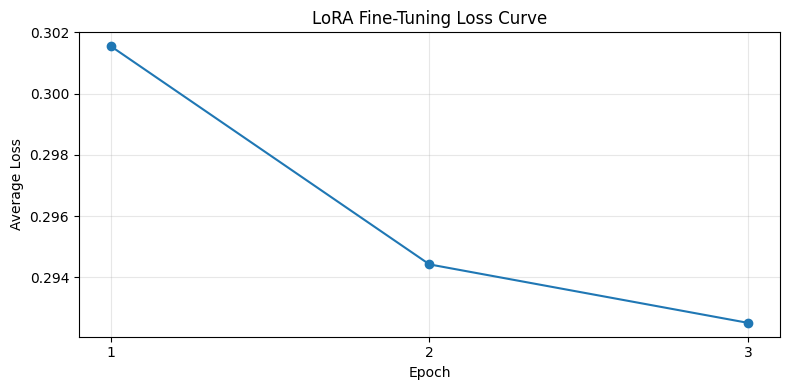

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(stats.average_losses) + 1), stats.average_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("LoRA Fine-Tuning Loss Curve")
plt.xticks(range(1, len(stats.average_losses) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
from conn import load_lora_encoder

loaded_encoder = load_lora_encoder(ADAPTER_DIR, base_model_name=MODEL_NAME)
print(f"Loaded LoRA encoder from {ADAPTER_DIR}")

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1642.81it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Loaded LoRA encoder from adapters/deberta-lora


In [9]:
from conn import (
    accuracy_min_swaps,
    accuracy_zero_one,
    evaluate,
)
from conn.solvers import FewShotSolver, BaselineGreedySolver


def gold_words_from_row(row):
    return [eg.words for eg in gold_example_groups_from_row(row)]


ft_contextual_solver = FewShotSolver(ft_encoder)
ft_static_solver = BaselineGreedySolver(ft_encoder)
base_static_solver = BaselineGreedySolver(encoder)


results = {}
for label, solver_fn in [
    ("LoRA (contextual / FewShotSolver)", ft_contextual_solver.solve),
    ("LoRA (static / BaselineGreedySolver)", ft_static_solver.solve),
    ("Base model (static / BaselineGreedySolver)", base_static_solver.solve),
]:
    metrics = [accuracy_zero_one, accuracy_min_swaps]
    results_dict = evaluate(
        eval_puzzles,
        metric_fns=metrics,
        solver_fn=solver_fn,
        gold_from_row=gold_words_from_row,
        verbose=VERBOSE,
    )
    acc, n = results_dict["accuracy_zero_one"]
    swaps, _ = results_dict["accuracy_min_swaps"]
    
    results[label] = (acc, swaps, n)
    print(f"{label}:")
    print(f"  Zero-one accuracy: {acc:.4f}  (n={n})")
    print(f"  Mean min-swaps:    {swaps:.2f}")
    print()

LoRA (contextual / FineTunedSolver):
  Zero-one accuracy: 0.0200  (n=50)
  Mean min-swaps:    3.52

LoRA (static / BaselineGreedySolver):
  Zero-one accuracy: 0.0000  (n=50)
  Mean min-swaps:    4.22

Base model (static / BaselineGreedySolver):
  Zero-one accuracy: 0.0000  (n=50)
  Mean min-swaps:    4.26




Fine-tuning with LoRA rank = 1
Starting LoRA fine-tuning on mps for 3 epochs...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2698.36it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Epoch 1/3 | Average Loss: 0.3037
Epoch 2/3 | Average Loss: 0.2938
Epoch 3/3 | Average Loss: 0.2925
Rank 1 Results - Acc: 0.0400, Swaps: 3.60, Final Loss: 0.2925

Fine-tuning with LoRA rank = 2
Starting LoRA fine-tuning on mps for 3 epochs...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2732.17it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Epoch 1/3 | Average Loss: 0.3013
Epoch 2/3 | Average Loss: 0.2951
Epoch 3/3 | Average Loss: 0.2932
Rank 2 Results - Acc: 0.0400, Swaps: 3.66, Final Loss: 0.2932

Fine-tuning with LoRA rank = 4
Starting LoRA fine-tuning on mps for 3 epochs...


...

Epoch 1/3 | Average Loss: 0.3018
Epoch 2/3 | Average Loss: 0.2942
Epoch 3/3 | Average Loss: 0.2916
Rank 4 Results - Acc: 0.0200, Swaps: 3.92, Final Loss: 0.2916

Fine-tuning with LoRA rank = 8
Starting LoRA fine-tuning on mps for 3 epochs...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2314.86it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Epoch 1/3 | Average Loss: 0.3015
Epoch 2/3 | Average Loss: 0.2944
Epoch 3/3 | Average Loss: 0.2925
Rank 8 Results - Acc: 0.0600, Swaps: 3.66, Final Loss: 0.2925

Fine-tuning with LoRA rank = 16
Starting LoRA fine-tuning on mps for 3 epochs...


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2926.06it/s, Materializing param=encoder.rel_embeddings.weight]                   
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignor

Epoch 1/3 | Average Loss: 0.3019
Epoch 2/3 | Average Loss: 0.2932
Epoch 3/3 | Average Loss: 0.2922
Rank 16 Results - Acc: 0.0400, Swaps: 3.56, Final Loss: 0.2922


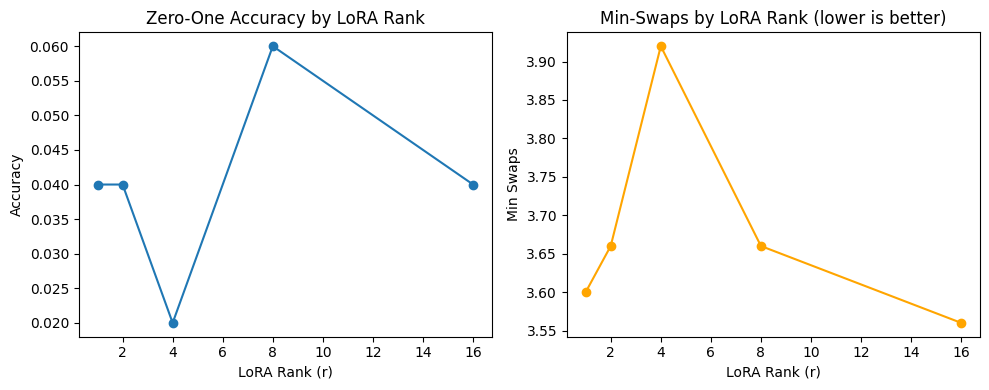

In [ ]:
ranks_to_try = [1, 2, 4, 8, 16]
rank_results = {}

for r in ranks_to_try:
    print(f"\n{'='*40}\nFine-tuning with LoRA rank = {r}\n{'='*40}")
    out_dir = f"{ADAPTER_DIR}_r{r}"
    
    # Train
    ft_encoder_r, stats_r = finetune_deberta_lora(
        puzzles=train_puzzles,
        model_name=MODEL_NAME,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        temperature=TEMPERATURE,
        lora_r=r,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        adapter_output_dir=out_dir,
        verbose=True,
    )
    
    # Evaluate contextual
    ft_solver_r = FewShotSolver(ft_encoder_r)
    solve_contextual_r = ft_solver_r.solve
        
    metrics = [accuracy_zero_one, accuracy_min_swaps]
    results_dict = evaluate(
        eval_puzzles,
        metric_fns=metrics,
        solver_fn=solve_contextual_r,
        gold_from_row=gold_words_from_row,
        verbose=False,
    )
    acc, n = results_dict["accuracy_zero_one"]
    swaps, _ = results_dict["accuracy_min_swaps"]
    
    rank_results[r] = {"acc": acc, "swaps": swaps, "loss": stats_r.average_losses[-1]}
    print(f"Rank {r} Results - Acc: {acc:.4f}, Swaps: {swaps:.2f}, Final Loss: {stats_r.average_losses[-1]:.4f}")

# Plot summary of ranks
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(list(rank_results.keys()), [v["acc"] for v in rank_results.values()], marker='o')
plt.title("Zero-One Accuracy by LoRA Rank")
plt.xlabel("LoRA Rank (r)")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(list(rank_results.keys()), [v["swaps"] for v in rank_results.values()], marker='o', color='orange')
plt.title("Min-Swaps by LoRA Rank (lower is better)")
plt.xlabel("LoRA Rank (r)")
plt.ylabel("Min Swaps")

plt.tight_layout()
plt.show()